# Финальный проект

Задачи для финального проекта:
1. Считать предоставленные данные
2. Поделить данные на train/test (4000 точек как входные параметры и 1000 точек как предсказание)
3. применить фильтр Калмана для приведения сигнала к менее зашумленному виду
4. Обучить модели
5. Произвести валидацию результатов обучения

### Импорт библиотек

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

from tslearn.neural_network import TimeSeriesMLPRegressor

plt.style.use("seaborn-v0_8")

### Загрузка данных

In [2]:
# Загружаем датасет
train_noisy = pd.read_csv('../data/train.csv', header=None).to_numpy(dtype=float)
train_clean = pd.read_csv('../data/etalon_for_train.csv', header=None).to_numpy(dtype=float)
test_noisy = pd.read_csv('../data/test.csv', header=None).to_numpy(dtype=float)
test_clean = pd.read_csv('../data/etalon_for_test.csv', header=None).to_numpy(dtype=float)

# Вывод
print('train_noisy:', train_noisy.shape)
print('train_clean:', train_clean.shape)
print('test_noisy :', test_noisy.shape)
print('test_clean :', test_clean.shape)

train_noisy: (1000, 5000)
train_clean: (1000, 5000)
test_noisy : (500, 5000)
test_clean : (500, 5000)


In [6]:
def estimate_kalman_params(noisy: np.ndarray, clean: np.ndarray, eps: float = 1e-8) -> dict:
    """
    Оценка параметров Калмана по эталонному чистому и зашумленному сигналам.
    """
    measurement_noise = noisy - clean
    process_increments = np.diff(clean, axis=1)
    q = float(np.var(process_increments) + eps)
    r = float(np.var(measurement_noise) + eps)
    x0 = float(np.mean(clean[:, 0]))
    p0 = float(np.var(clean[:, 0]) + r)
    return {'q': q, 'r': r, 'x0': x0, 'p0': p0}


def kalman_filter_1d(signal: np.ndarray, q: float, r: float, x0: float | None = None, p0: float | None = None) -> np.ndarray:
    """
    Одномерный фильтр Калмана для одного временного ряда.
    """
    x_hat = float(signal[0] if x0 is None else x0)
    p = float(max(r, 1e-8) if p0 is None else p0)
    filtered = np.empty_like(signal, dtype=float)

    for i, y in enumerate(signal):
        p = p + q
        k = p / (p + r)
        x_hat = x_hat + k * (y - x_hat)
        p = (1.0 - k) * p
        filtered[i] = x_hat

    return filtered


def apply_kalman_filter(noisy: np.ndarray, params: dict) -> np.ndarray:
    """
    Применение фильтра Калмана к пакету сигналов (каждая строка - отдельный ряд).
    """
    return np.vstack([
        kalman_filter_1d(signal, params['q'], params['r'], params['x0'], params['p0'])
        for signal in noisy
    ])


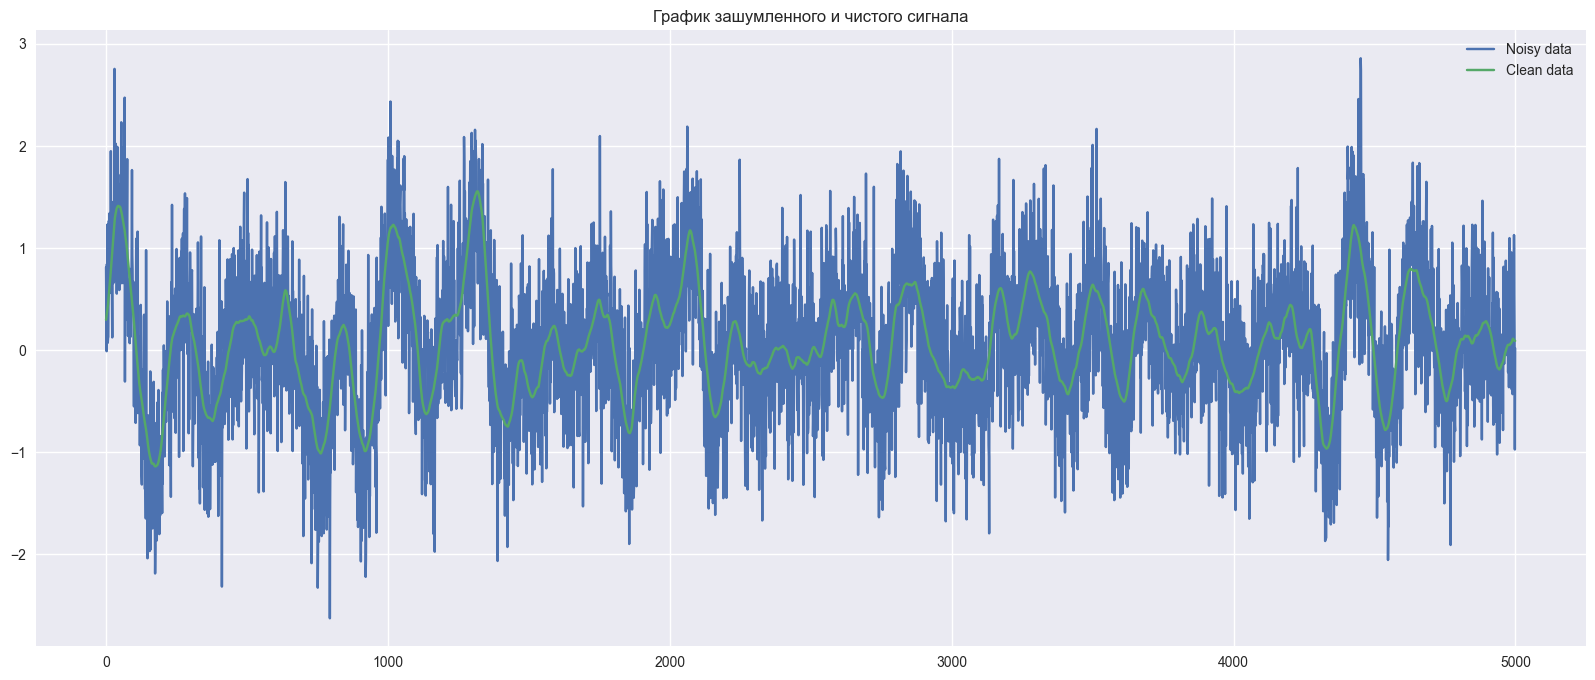

In [7]:
plt.figure(figsize=(20,8))
plt.plot(train_noisy[0], label = "Noisy data")
plt.plot(train_clean[0], label = "Clean data")
plt.legend()
plt.title(f"График зашумленного и чистого сигнала")
plt.show()

### Работа с данными

In [8]:
# Разделение данных
split = 4000
x_train_noisy, x_val_noisy = train_noisy[:, :split], train_noisy[:, split:]
x_train_clean, x_val_clean = train_clean[:, :split], train_clean[:, split:]

x_test_noisy, x_test_val_noisy = test_noisy[:, :split], test_noisy[:, split:]
x_test_clean, x_test_val_clean = test_clean[:, :split], test_clean[:, split:]

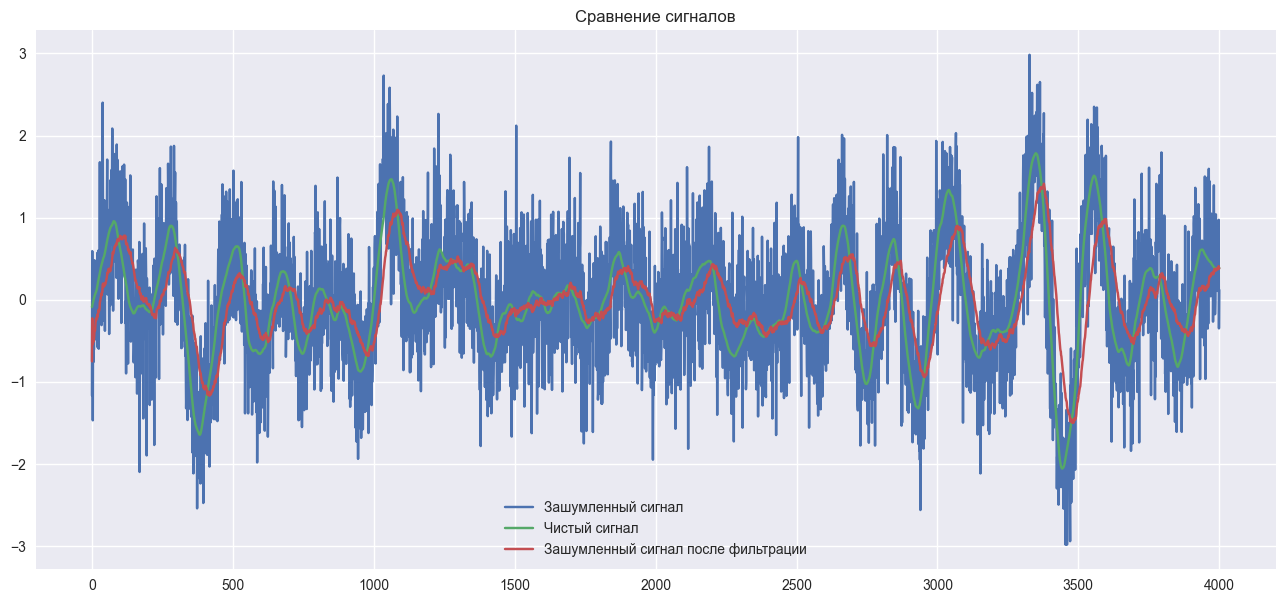

In [9]:
# Фильтрация шума фильтром Калмана
kalman_params = estimate_kalman_params(x_train_noisy[:, :split], x_train_clean[:, :split])

def mean_forecast_error(L, true, preds):
    print(true.shape, preds.shape)
    return (true + preds).sum(axis=1, keepdims=True) / L

def RMS(L, true, preds):
    delta = mean_forecast_error(L, true.T, preds.T)
    result = []
    for i in range(len(true)):
        subdelta = np.sqrt(np.sum(np.square(true[i]-preds[i]-delta[i]))/(L-1))
        result.append(subdelta)
    return result


idx = 10
plt.figure(figsize=(16,7))
x_1 = np.linspace(0,4000,4000)
plt.plot(x_1,x_train_noisy[idx], label = "Зашумленный сигнал")
plt.plot(x_1,x_train_clean[idx], label = "Чистый сигнал")
plt.plot(x_1,apply_kalman_filter(x_train_noisy, kalman_params)[idx], label = "Зашумленный сигнал после фильтрации")
plt.title('Сравнение сигналов')
plt.legend()

### Обучение моделей

In [35]:
model = TimeSeriesMLPRegressor(
    hidden_layer_sizes=(100, 50, 50),  # три слоя
    activation='relu', solver='adam', max_iter=500, verbose=True
)
model.fit(apply_kalman_filter(x_train_noisy, kalman_params), x_val_clean)

Iteration 1, loss = 0.13961602
Iteration 2, loss = 0.13823668
Iteration 3, loss = 0.13743596
Iteration 4, loss = 0.13630054
Iteration 5, loss = 0.13442119
Iteration 6, loss = 0.13168294
Iteration 7, loss = 0.12780387
Iteration 8, loss = 0.12281692
Iteration 9, loss = 0.11697189
Iteration 10, loss = 0.11021450
Iteration 11, loss = 0.10365874
Iteration 12, loss = 0.09739097
Iteration 13, loss = 0.09191327
Iteration 14, loss = 0.08707050
Iteration 15, loss = 0.08265287
Iteration 16, loss = 0.07908460
Iteration 17, loss = 0.07598140
Iteration 18, loss = 0.07318407
Iteration 19, loss = 0.07070331
Iteration 20, loss = 0.06848554
Iteration 21, loss = 0.06639997
Iteration 22, loss = 0.06421258
Iteration 23, loss = 0.06225900
Iteration 24, loss = 0.06065749
Iteration 25, loss = 0.05948886
Iteration 26, loss = 0.05803543
Iteration 27, loss = 0.05697957
Iteration 28, loss = 0.05598338
Iteration 29, loss = 0.05487792
Iteration 30, loss = 0.05408817
Iteration 31, loss = 0.05325696
Iteration 32, los

TimeSeriesMLPRegressor(hidden_layer_sizes=(100, 50, 50), max_iter=500,
                       verbose=True)

In [36]:
preds = model.predict(apply_kalman_filter(x_test_noisy, kalman_params))
mean_squared_error(preds, x_test_val_clean)

D:\JetBrains\PyCharm\Python\Lib\site-packages\tslearn\utils\utils.py:129: UserWarning: 2-Dimensional data passed. Assuming these are 500 1-dimensional timeseries
  warnings.warn(


0.5896663741737879

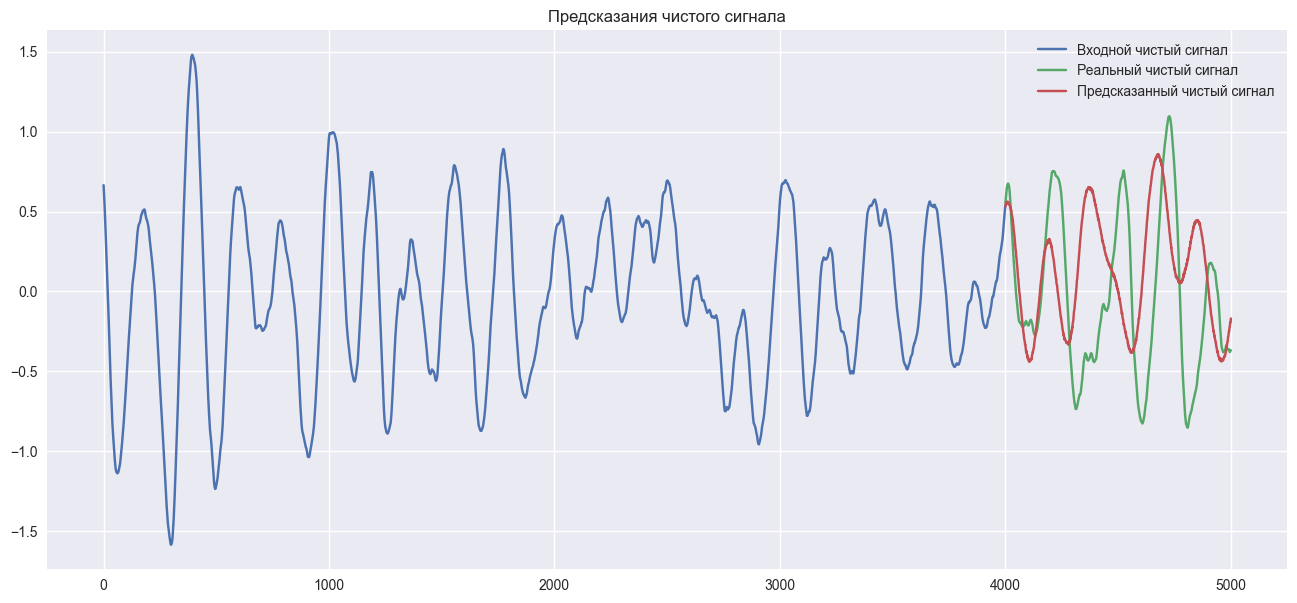

In [37]:
idx = 10
plt.figure(figsize=(16,7))
x_1 = np.linspace(0,4000,4000)
plt.plot(x_1,x_test_clean[idx], label = "Входной чистый сигнал")
x_2 = np.linspace(4000,5000,1000)
plt.plot(x_2,x_test_val_clean[idx], label = "Реальный чистый сигнал")
plt.plot(x_2,preds[idx], label = "Предсказанный чистый сигнал")
plt.title('Предсказания чистого сигнала')
plt.legend()

(1000, 500) (1000, 500)


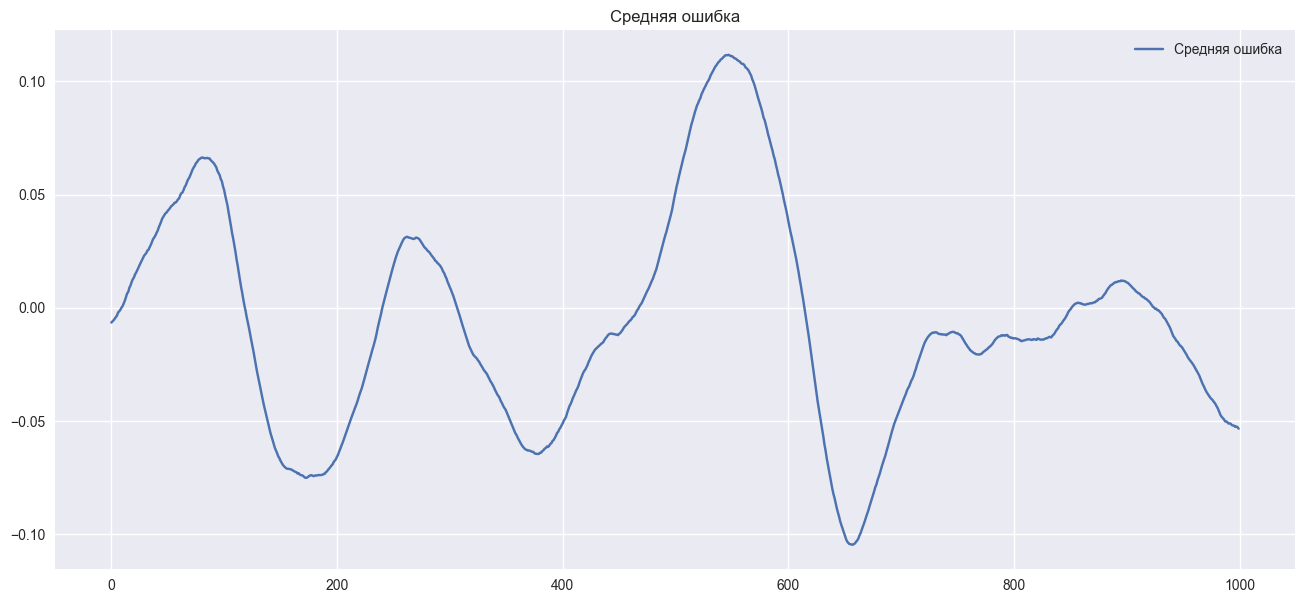

In [38]:
idx = 1
plt.figure(figsize=(16,7))
plt.plot(mean_forecast_error(len(preds), preds.T, x_test_val_clean.T), label = "Средняя ошибка")
plt.title('Средняя ошибка')
plt.legend()

(1000, 500) (1000, 500)


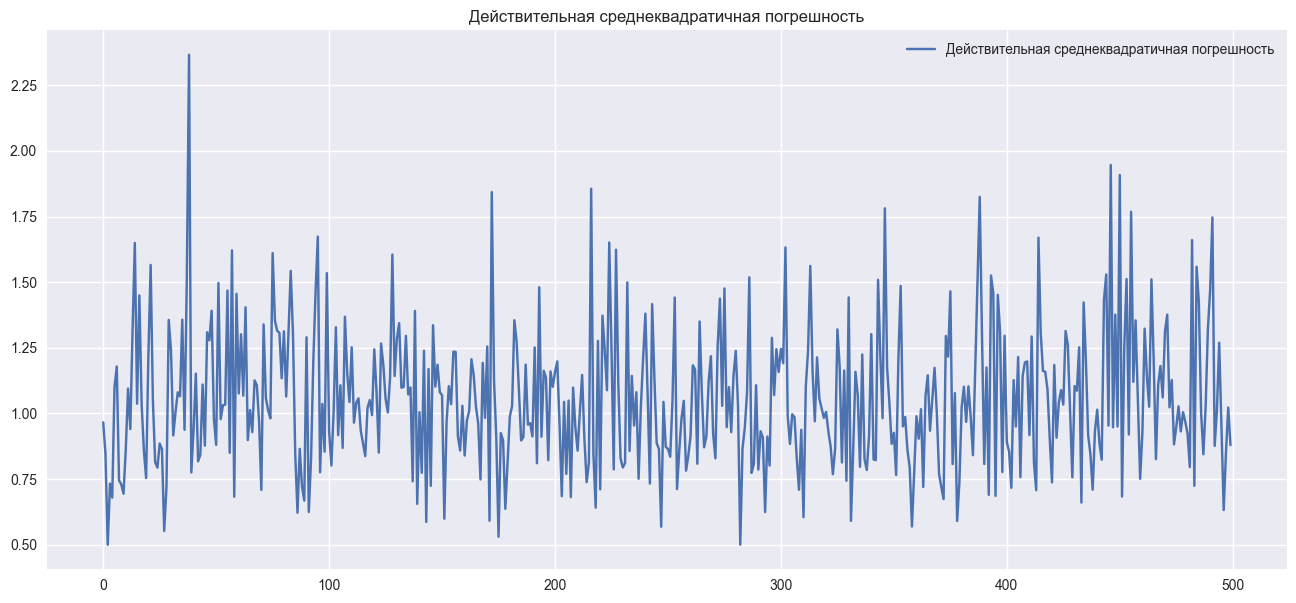

In [39]:
idx = 1
plt.figure(figsize=(16,7))
plt.plot(RMS(len(preds), preds, x_test_val_clean), label = "Действительная среднеквадратичная погрешность")
plt.title('Действительная среднеквадратичная погрешность')
plt.legend()
